# Portfolio optimization

In this project, I'm trying to build a portfolio using mean variance optimization. The idea isn't just to find the best portfolio in hindsight, but to build a system that adapts over time. 

First, I need to define my investment universe. I've selected a broad mix of ETFs to give the optimizer enough variety to work with. This includes core equities (US and International), smart beta factors (momentum, value), specific sectors for defense and offense, bonds for yield/safety, and alternative assets like gold and real estate to hedge against inflation.


### 1. Data collection and preprocessing

Now let's pull the historical data using `yfinance`. I'm going to resample the daily closing prices into monthly data. Daily data is way too noisy for longterm strategic allocation and can mess up the covariance estimations. 

Also, since some of these ETFs were created later than others, I need to find the "youngest" ETF and cut all the data to start from that date. If we have missing data (`NaN`s) early on, the covariance matrix won't calculate correctly.

In [67]:
import yfinance as yf
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

etfs = {
    # core
    "SPY": "S&P 500",
    "VEA": "Developed Markets",
    "VWO": "Emerging Markets",
    "IWM": "Russell 2000",
    "QQQ": "Nasdaq 100",
    "EWJ": "Japan",

    # smart,beta
    "MTUM": "Momentum",
    "QUAL": "Quality",
    "VLUE": "Value",
    "USMV": "Min Vol",

    # sectors
    "XLK": "Technology",
    "XLF": "Financials",
    "XLE": "Energy",
    "XLV": "Healthcare",
    "XLU": "Utilities",       
    "XLP": "Consumer Staples",

    # bonds
    "AGG": "Aggregate Bonds",
    "TLT": "20Y Treasury",
    "IEF": "7-10Y Treasury",
    "LQD": "Corporate Bonds",
    "HYG": "High Yield",
    "TIP": "TIPS (Inflation)",
    "EMB": "EM Bonds",         
   
    # alternatives
    "GLD": "Gold",
    "SLV": "Silver",
    "DBC": "Commodities",
    "VNQ": "REITs",
}



all_prices = {}

print("Downloading data")
for ticker in etfs.keys():

    try:
        df = yf.download(
            ticker,
            period="max",
            auto_adjust=True,
            progress=False
        )

        if len(df) == 0:
            print(f"Skipping {ticker} (empty)")
            continue

        prices = df["Close"].squeeze().rename(ticker)

        all_prices[ticker] = prices

        #print(f"Downloaded {ticker}")

    except Exception as e:
        print(f"Failed {ticker}: {e}")


#merge into dataframe
prices = pd.concat(all_prices.values(), axis=1)


# Monthly prices
monthly_prices = prices.resample("ME").last()


# Find youngest ETF start date
first_dates = monthly_prices.apply(lambda col: col.first_valid_index())

youngest_start = first_dates.max()

print("\nYoungest ETF inception:")
print(youngest_start)


# Align all ETFs
monthly_prices = monthly_prices.loc[youngest_start:]

monthly_prices = monthly_prices.dropna()

# Monthly returns
monthly_returns = monthly_prices.pct_change().dropna()


n_years = len(monthly_returns) / 12

cagr = (
    monthly_prices.iloc[-1] /
    monthly_prices.iloc[0]
) ** (1 / n_years) - 1



volatility = monthly_returns.std() * np.sqrt(12)


summary = pd.DataFrame({
    "CAGR": cagr,
    "Volatility": volatility
})

summary = summary.sort_values("CAGR", ascending=False)

print(summary.head())
print(monthly_returns.head())

monthly_returns.to_csv("monthly_returns.csv")
summary.to_csv("etf_summary.csv")

print("\nSaved CSV files.")


Youngest ETF inception:
2013-07-31 00:00:00
          CAGR  Volatility
XLK   0.222393    0.189131
QQQ   0.200708    0.178154
MTUM  0.157678    0.161614
SPY   0.141262    0.144825
QUAL  0.134605    0.146988
                 SPY       VEA       VWO       IWM       QQQ       EWJ  \
Date                                                                     
2013-08-31 -0.029992 -0.016021 -0.034306 -0.031642 -0.003959 -0.031194   
2013-09-30  0.031646  0.078505  0.072750  0.064891  0.048322  0.096596   
2013-10-31  0.046307  0.032087  0.043360  0.024200  0.049570 -0.000839   
2013-11-30  0.029638  0.006610 -0.009315  0.039564  0.035512  0.012594   
2013-12-31  0.025927  0.018981 -0.002846  0.020211  0.029271  0.014243   

                MTUM      QUAL      VLUE      USMV  ...       TLT       IEF  \
Date                                                ...                       
2013-08-31 -0.035635 -0.020751 -0.030386 -0.032573  ... -0.013404 -0.014225   
2013-09-30  0.030128  0.038079  0.027

### 2. Basic stats & correlation

Before doing any complex math, it's good to just look at the raw performance. I'm calculating the Compound Annual Growth Rate (CAGR) and the annualized volatility for each ETF.

Also generating a correlation matrix. The whole point of diversification is to find assets that don't move exactly together. If two assets have a correlation close to $1$, holding both doesn't reduce risk. We want to see some dark blue/purple spots in that matrix.

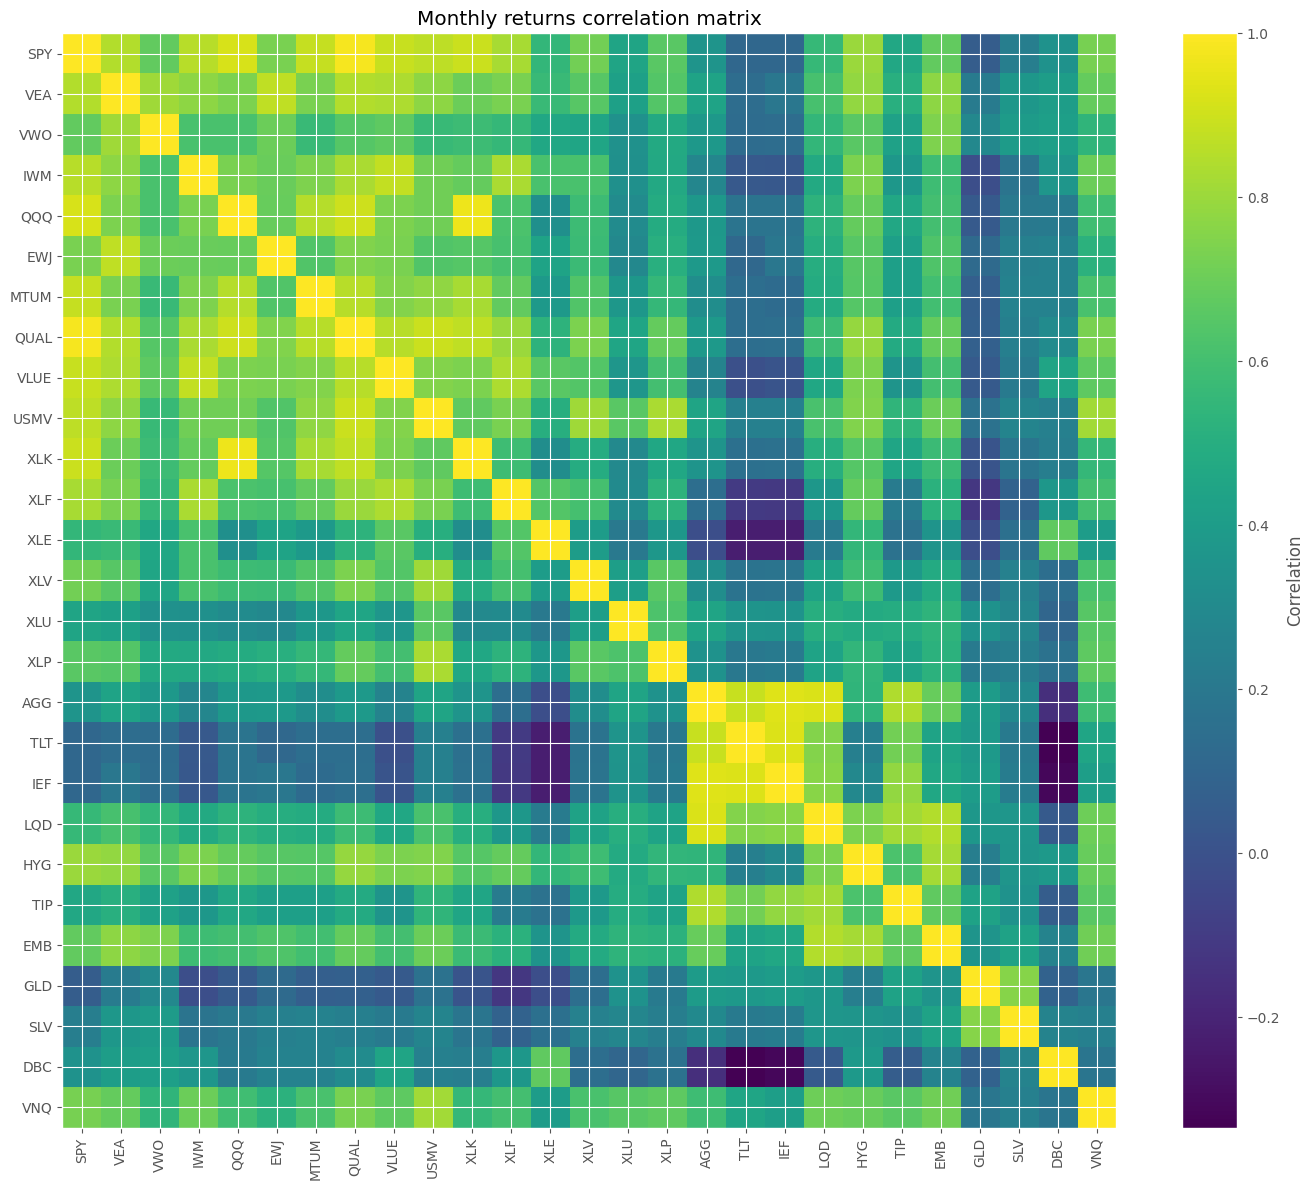

In [68]:
import matplotlib.pyplot as plt


cov_matrix = monthly_returns.corr()


fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(cov_matrix, aspect='auto')

# Tickers
ax.set_xticks(range(len(cov_matrix.columns)))
ax.set_yticks(range(len(cov_matrix.columns)))

ax.set_xticklabels(cov_matrix.columns, rotation=90)
ax.set_yticklabels(cov_matrix.columns)

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Correlation")

plt.title("Monthly returns correlation matrix")

plt.tight_layout()
plt.show()

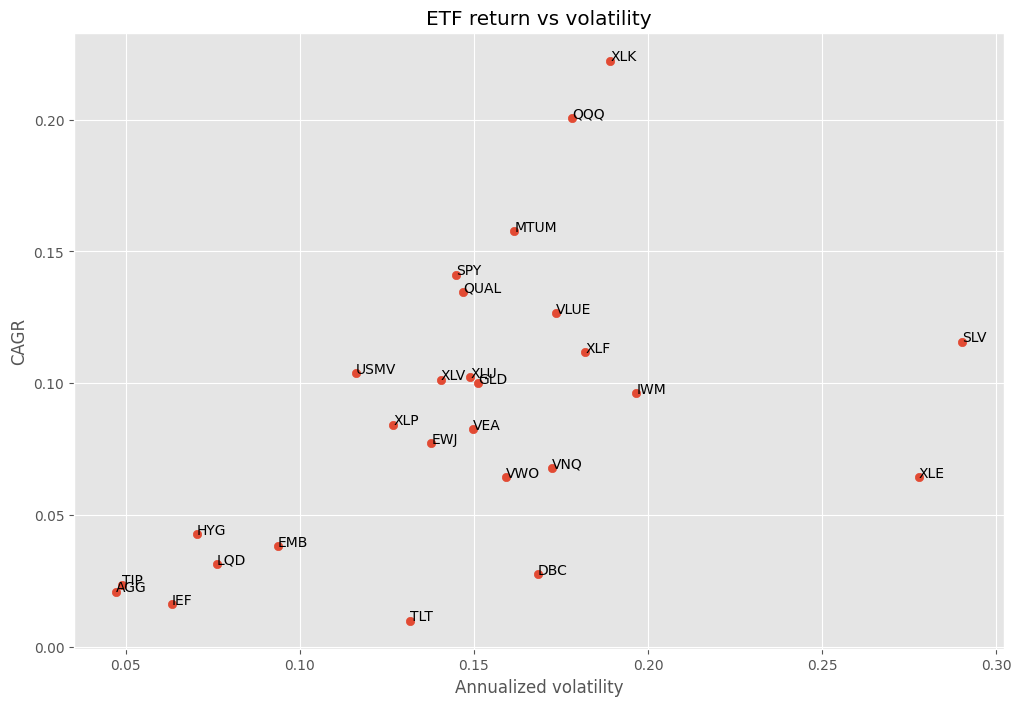

In [69]:

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    summary["Volatility"],
    summary["CAGR"]
)

# Labels
for ticker in summary.index:
    ax.annotate(
        ticker,
        (
            summary.loc[ticker, "Volatility"],
            summary.loc[ticker, "CAGR"]
        )
    )

ax.set_xlabel("Annualized volatility")
ax.set_ylabel("CAGR")
ax.set_title("ETF return vs volatility")

plt.grid(True)
plt.show()

### 3. Markowitz mean variance optimization

I'm using Modern Portfolio Theory (Markowitz, 1952) to find the optimal weights. The goal is to maximize our expected return for a given level of risk, or conversely, minimize risk for a target return.

Let $n$ be the number of ETFs in our universe. To set up the math, we define:
*   $w$: An $n \times 1$ column vector of portfolio weights.
*   $\mu$: An $n \times 1$ column vector of historical expected returns.
*   $\Sigma$: The $n \times n$ covariance matrix of the asset returns.

To understand how risk is calculated, we have to look inside the covariance matrix $\Sigma$. It captures not just the individual risk of each ETF, but how they move together:

$$ \Sigma = \begin{pmatrix} 
\sigma_1^2 & \sigma_{12} & \dots & \sigma_{1n} \\ 
\sigma_{21} & \sigma_2^2 & \dots & \sigma_{2n} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
\sigma_{n1} & \sigma_{n2} & \dots & \sigma_n^2 
\end{pmatrix} $$

The diagonal elements ($\sigma_i^2$) are the variances of the individual ETFs. The off diagonal elements ($\sigma_{ij}$) represent the covariance between asset $i$ and asset $j$, which can also be written as $\sigma_{ij} = \rho_{ij} \sigma_i \sigma_j$ (where $\rho$ is the correlation). 

By multiplying the weight vector by this matrix ($w^T \Sigma w$), we calculate the total portfolio variance ($\sigma_p^2$). This allows the math to automatically reward diversification.

The objective function I am maximizing is a quadratic utility function:

$$ \max_{w} \left( w^T \mu - \gamma w^T \Sigma w \right) $$

Here, $\gamma$ (gamma) is our risk aversion parameter. 
*   If $\gamma = 0$, the penalty for variance disappears, and the solver just puts 100% of the money into the single asset with the highest historical $\mu$. (but still subject to our constraints, so in 3 top performing assets)
*   As $\gamma$ increases, the $- \gamma w^T \Sigma w$ term heavily penalizes volatility, forcing the solver to find a safer, more diversified mix.

I'm formulating this as a Mixed Integer Quadratic Programming (MIQP) problem using `cvxpy`, introducing a boolean vector $z \in \{0, 1\}^n$ to act as an "on/off" switch for each asset.

Subject to the constraints:
1.  Fully Invested (no leverage): $\sum_{i=1}^n w_i = 1$
2.  Maximum Allocation: $w_i \le 0.70 z_i$ (Caps single-asset exposure at 70%).
3.  Minimum Allocation: $w_i \ge 0.03 z_i$ (If an asset is included, it must be at least 3% of the portfolio. This kills off useless 0.1% dust positions).
4.  Minimum Diversification: $\sum_{i=1}^n z_i \ge 3$ (Forces the portfolio to hold at least 3 different ETFs).

In [70]:
def get_optimal_weights(training_data, gamma, min_alloc=0.03, max_alloc=0.70, min_etfs=3):
    
    #returns optimal portfolio weights based on the given training data and risk aversion level.
    
    n = len(training_data.columns)
    
    
    mu = training_data.mean().values * 12
    Sigma = training_data.cov().values * 12
    
  
    w = cp.Variable(n)
    z = cp.Variable(n, boolean=True)
    
    risk = cp.quad_form(w, Sigma)
    ret = mu @ w
    
    constraints = [
        cp.sum(w) == 1,
        w >= min_alloc * z,
        w <= max_alloc * z,
        cp.sum(z) >= min_etfs,
    ]
    
    objective = cp.Maximize(ret - gamma * risk)
    problem = cp.Problem(objective, constraints)
    
    #
    try:
        problem.solve(solver=cp.GUROBI, verbose=False)
        if w.value is None:
            raise ValueError("Infeasible")
        weights = w.value
    except Exception as e:
        print(f"rip: {e}")
        weights = np.ones(n) / n
        
   
    weights = np.where(weights < 0.01, 0, weights)
    
    if np.sum(weights) > 0:
        weights = weights / np.sum(weights)
    else:
        
        weights = np.ones(n) / n 
        
   
    return pd.Series(weights, index=training_data.columns)

### 4. Tuning risk aversion ($\gamma$)

So, what should $\gamma$ be? Instead of guessing, let's run the optimizer across a spectrum of $\gamma$ values on our full dataset. We can plot the resulting equity curves to see how "aggressive" vs "conservative" the allocations get. I'll also plot the S&P 500 (SPY) as a baseline benchmark.

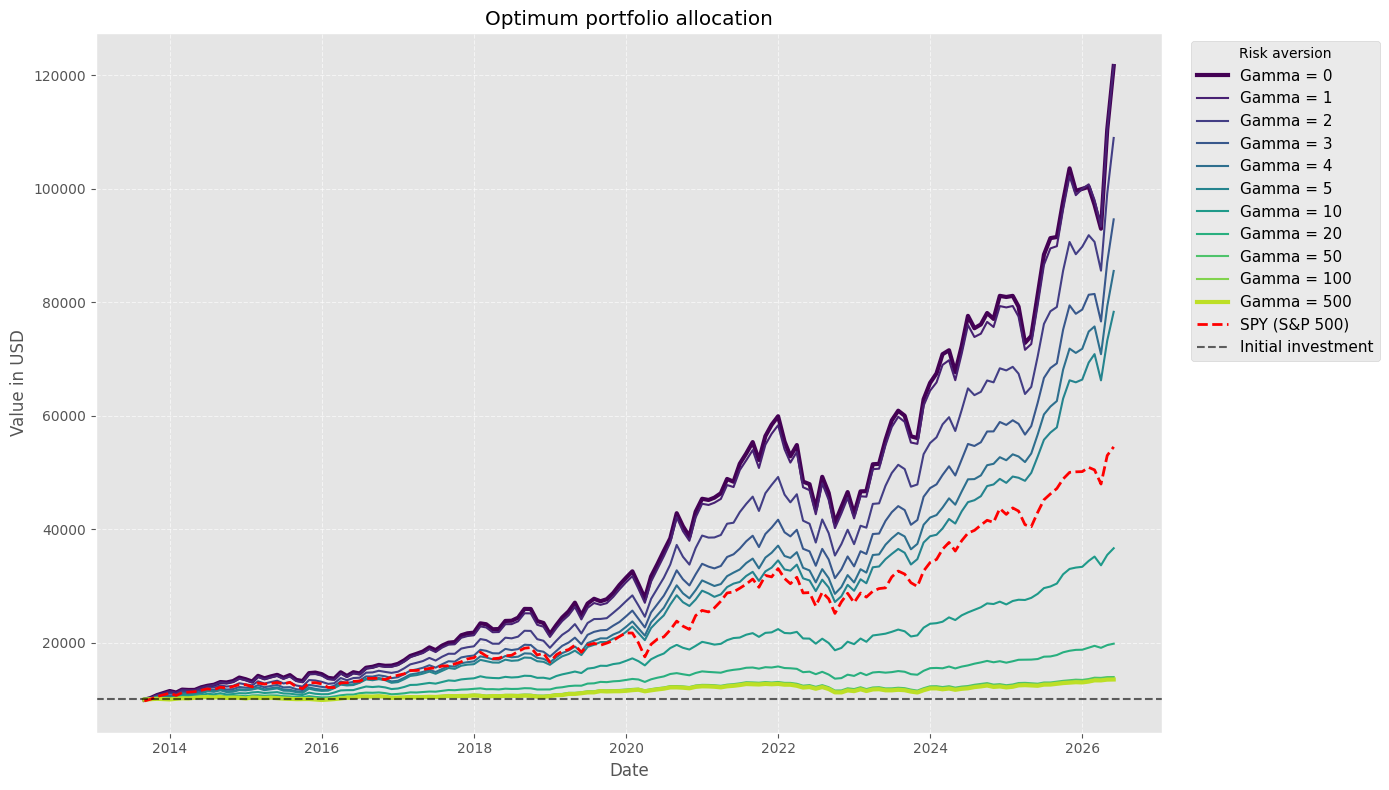

 Gamma Final values $ Total return %
  0    $121,656.73    1116.57 %     
  1    $121,813.76    1118.14 %     
  2    $108,968.33     989.68 %     
  3     $94,617.29     846.17 %     
  4     $85,515.78     755.16 %     
  5     $78,312.89     683.13 %     
 10     $36,623.22     266.23 %     
 20     $19,794.06      97.94 %     
 50     $13,914.59      39.15 %     
100     $13,485.98      34.86 %     
500     $13,479.43      34.79 %     


In [71]:


def analyze_risk_aversion(monthly_returns, gammas=[0, 1,2,3,4, 5, 10, 20, 50, 100, 500], initial_investment=10000):
    """
    optimize portfolio for different levels of risk aversion (gamma)
    """
    n = len(monthly_returns.columns)
    

    mu = monthly_returns.mean().values * 12
    Sigma = monthly_returns.cov().values * 12
    

    plt.style.use('ggplot')
    plt.figure(figsize=(14, 8))
    
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(gammas)))
    
    results_summary = []
        
   
    for i, gamma in enumerate(gammas):
        
        weights = get_optimal_weights(monthly_returns, gamma)
        
        # equity curve for given gamma
        portfolio_returns = monthly_returns.dot(weights)
        equity_curve = initial_investment * (1 + portfolio_returns).cumprod()
        

        lw = 3 if gamma in [gammas[0], gammas[-1]] else 1.5
        plt.plot(equity_curve.index, equity_curve, color=colors[i], linewidth=lw, label=f'Gamma = {gamma}')
        
        
        final_value = equity_curve.iloc[-1]
        total_return_pct = ((final_value / initial_investment) - 1) * 100
        results_summary.append({
            'Gamma': gamma,
            'Final values $': final_value,
            'Total return %': total_return_pct
        })
        
    #plot also spy for reference
    spy_returns = monthly_returns['SPY']
    spy_equity_curve = initial_investment * (1 + spy_returns).cumprod()
    plt.plot(spy_equity_curve.index, spy_equity_curve, color='red', linestyle='--', linewidth=2, label='SPY (S&P 500)')


    # 4. Kosmetika grafu
    plt.axhline(y=initial_investment, color='black', linestyle='--', alpha=0.6, label='Initial investment')
    
    plt.title('Optimum portfolio allocation')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Value in USD', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    

    plt.legend(title="Risk aversion", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()
    

    df_summary = pd.DataFrame(results_summary)
    

    df_summary['Final values $'] = df_summary['Final values $'].apply(lambda x: f"${x:,.2f}")
    df_summary['Total return %'] = df_summary['Total return %'].apply(lambda x: f"{x:.2f} %")
    
  
    print(df_summary.to_string(index=False, justify='left'))

analyze_risk_aversion(monthly_returns)

### 5. Walk forward backtesting (out of sample testing)

It's always easy to look at historical data and overfit the backtest. The optimizer now "knows" the 2020 COVID dip is coming etc..

To see how this strategy would actually perform, I'm building a walk forward backtest. 
1. We take a past window of data (e.g., `lookback_months = 72`).
2. We train the optimizer on that window to get our weights.
3. We hold that portfolio "out of sample" for a set period (e.g., `step_months = 12`).
4. We slide the window forward and repeat.

This simulates how a real investor would periodically rebalance their portfolio using only the data available to them at that moment. We use gamma = 5

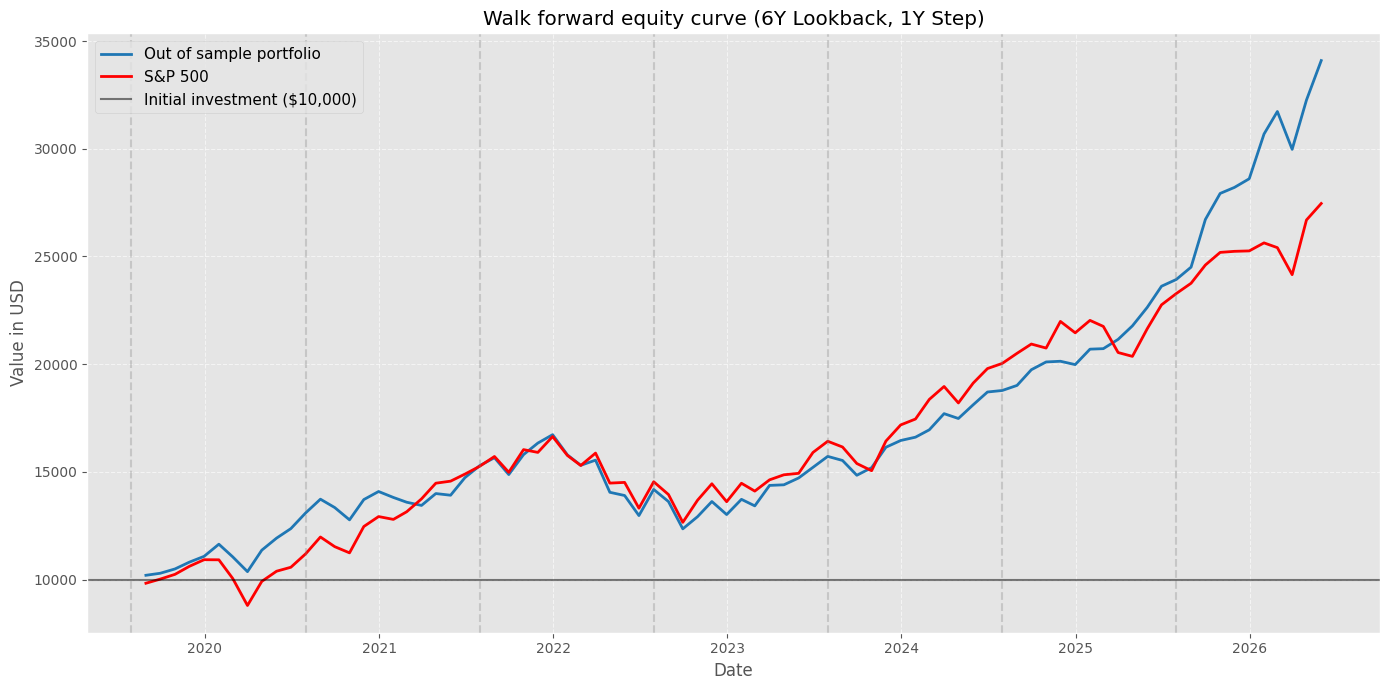

Initial value:  $10,000.00
Final value:    $34,092.99
Total return:      240.93 %
Annualized return: 19.66 % p.a.
Max drawdown:       -26.13 %
Max drawdown ($):   $-4,371.56


In [72]:

lookback_months = 72 
step_months = 12      
n = len(monthly_returns.columns)


oos_portfolio_returns = []
rebalance_records = [] #


total_months = len(monthly_returns)


#loop through history
for start_idx in range(0, total_months - lookback_months, step_months):
    
    # definition of train and test window
    train_end_idx = start_idx + lookback_months
    test_end_idx = min(train_end_idx + step_months, total_months)
    
    train_data = monthly_returns.iloc[start_idx:train_end_idx]
    test_data = monthly_returns.iloc[train_end_idx:test_end_idx]
    
    if test_data.empty:
        break
        
    rebalance_date = train_data.index[-1]
   
    weights = get_optimal_weights(train_data, gamma=5) 
    
    #saving for later
    rebalance_records.append(pd.Series(weights, index=monthly_returns.columns, name=rebalance_date))

    # application on out of sample test data
    period_returns = test_data.dot(weights)
    oos_portfolio_returns.append(period_returns)



# get all out of sample returns in one series
oos_series = pd.concat(oos_portfolio_returns)
spy_oos_returns = monthly_returns['SPY'].loc[oos_series.index]



initial_investment = 10000
equity_curve = initial_investment * (1 + oos_series).cumprod()
spy_equity_curve = initial_investment * (1 + spy_oos_returns).cumprod()

plt.figure(figsize=(14, 7))


plt.plot(equity_curve.index, equity_curve, color='#1f77b4', linewidth=2, label='Out of sample portfolio')
plt.plot(spy_equity_curve.index, spy_equity_curve, color='red', linewidth=2, label='S&P 500')

for r_date in [record.name for record in rebalance_records]:
    plt.axvline(x=r_date, color='gray', linestyle='--', alpha=0.3)

plt.axhline(y=initial_investment, color='black', linestyle='-', alpha=0.5, label='Initial investment ($10,000)')


plt.title(f'Walk forward equity curve ({lookback_months // 12}Y Lookback, 1Y Step)')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value in USD', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

plt.show()


final_value = equity_curve.iloc[-1]
total_return_pct = ((final_value / initial_investment) - 1) * 100
annualized_return = ((final_value / initial_investment) ** (1 / (len(oos_series) / 12)) - 1) * 100
peak = equity_curve.cummax()
drawdown = (equity_curve - peak) / peak

max_drawdown_pct = drawdown.min() * 100
max_drawdown_value = (equity_curve - peak).min()

print(f"Initial value:  ${initial_investment:,.2f}")
print(f"Final value:    ${final_value:,.2f}")
print(f"Total return:      {total_return_pct:.2f} %")
print(f"Annualized return: {annualized_return:.2f} % p.a.")
print(f"Max drawdown:       {max_drawdown_pct:.2f} %")
print(f"Max drawdown ($):   ${max_drawdown_value:,.2f}")

## 5.1 Holdings visualisation
This area chart shows the portfolio weights at each rebalancing step. It's interesting to see if it flees to bonds/gold during market turbulence or piles into tech during bull runs.


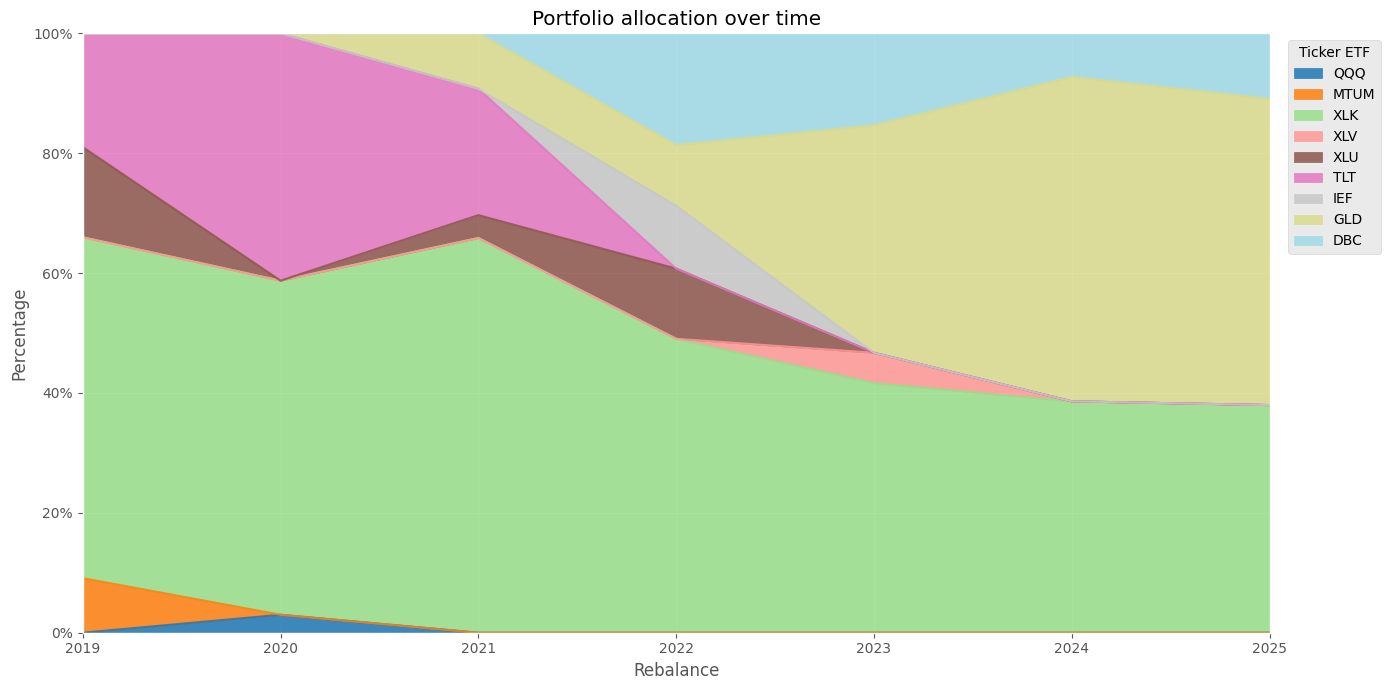

In [73]:

import matplotlib.ticker as mtick

df_weights_history = pd.DataFrame(rebalance_records)


df_weights_history = df_weights_history.loc[:, (df_weights_history > 0).any(axis=0)]


plt.figure(figsize=(14, 7))


df_weights_history.plot.area(ax=plt.gca(), colormap='tab20', alpha=0.85)


plt.title('Portfolio allocation over time')
plt.xlabel('Rebalance', fontsize=12)
plt.ylabel('Percentage', fontsize=12)


plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 1) 


plt.legend(title='Ticker ETF', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### 6. Parameter sensitivity & grid search

For the walk forward test above, I just arbitrarily picked a 6 year lookback and a 1 year rebalance step. But are those the best parameters? Does rebalancing more frequently hurt us due to noise, or help us catch trends?

To figure this out, I'm running a grid search. I will loop through various combinations of `lookback` and `step` windows, run the entire walk forward backtest for each combination, and record the annualized return and volatility. 

Finally, I'll plot these results on heatmaps. We are looking for "stable neighborhoods" if 36 months lookback is great, but 24 and 48 are terrible, the strategy is overfitted. We want to find an area on the heatmap that is consistently green.

Running grid search


Grid search progress:  12%|█▎        | 8/64 [00:02<00:08,  6.51it/s]

rip: ARPACK error -1: ARPACK error -1: No convergence (271 iterations, 0/1 eigenvectors converged)


        CVXPY note: This failure was encountered while trying to certify
        that a matrix is positive semi-definite (see [1] for a definition).
        In rare cases, this method fails for numerical reasons even when the matrix is
        positive semi-definite. If you know that you're in that situation, you can
        replace the matrix A by cvxpy.psd_wrap(A).

        [1] https://en.wikipedia.org/wiki/Definite_matrix
        
rip: ARPACK error -1: ARPACK error -1: No convergence (271 iterations, 0/1 eigenvectors converged)


        CVXPY note: This failure was encountered while trying to certify
        that a matrix is positive semi-definite (see [1] for a definition).
        In rare cases, this method fails for numerical reasons even when the matrix is
        positive semi-definite. If you know that you're in that situation, you can
        replace the matrix A by cvxpy.psd

Grid search progress: 100%|██████████| 64/64 [00:21<00:00,  3.00it/s]


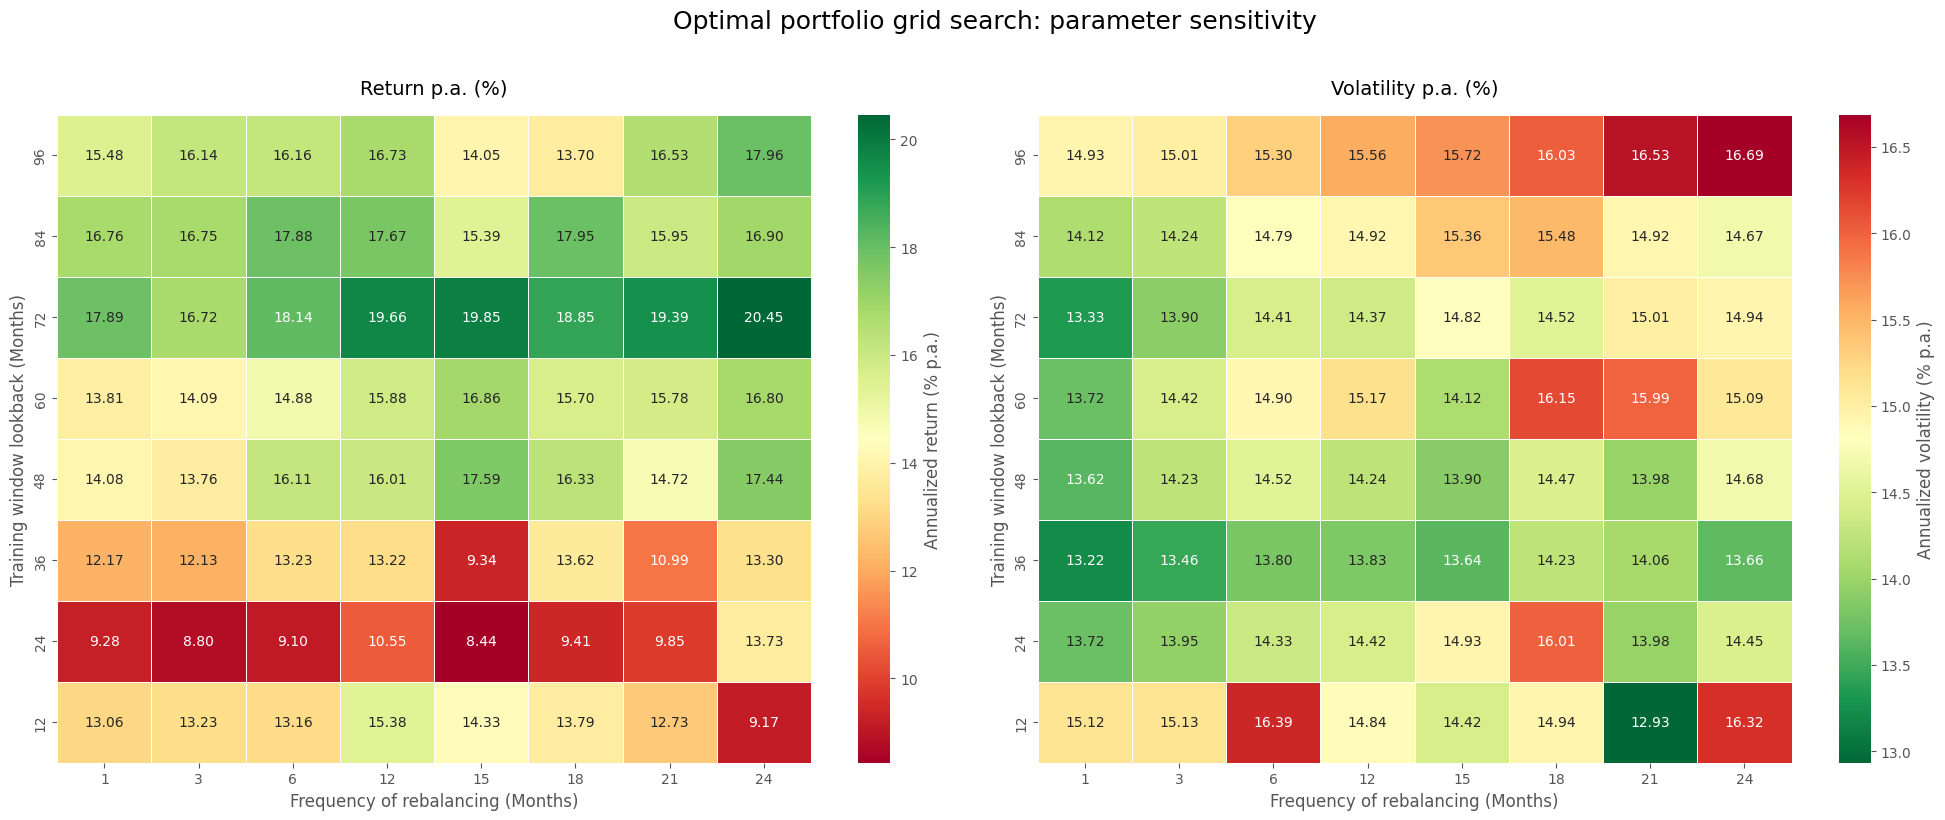

In [74]:
import seaborn as sns
from tqdm import tqdm 


def run_walk_forward_backtest(lookback_months, step_months, returns_df):
    n = len(returns_df.columns)
    total_months = len(returns_df)
    oos_portfolio_returns = []
    
    
    for start_idx in range(0, total_months - lookback_months, step_months):
        train_end_idx = start_idx + lookback_months
        test_end_idx = min(train_end_idx + step_months, total_months)
        
        train_data = returns_df.iloc[start_idx:train_end_idx]
        test_data = returns_df.iloc[train_end_idx:test_end_idx]
        
        if test_data.empty: break
            
        weights = get_optimal_weights(train_data, gamma=5)
            
        period_returns = test_data.dot(weights)
        oos_portfolio_returns.append(period_returns)
        
    if not oos_portfolio_returns:
        return np.nan
        
    oos_series = pd.concat(oos_portfolio_returns)
    cumulative_return = (1 + oos_series).prod()
    years_invested = len(oos_series) / 12
    
    if years_invested == 0: return np.nan
    
    annualized_return = ((cumulative_return ** (1 / years_invested)) - 1) * 100
    annualized_volatility = oos_series.std() * np.sqrt(12) * 100
    return annualized_return, annualized_volatility

# grid search settings
lookback_grid = [12, 24, 36, 48, 60, 72, 84, 96] 
step_grid = [1, 3, 6, 12,15,18,21,24]               

results = []

print("Running grid search")


total_iterations = len(lookback_grid) * len(step_grid)
with tqdm(total=total_iterations, desc="Grid search progress") as pbar:
    for lookback in lookback_grid:
        for step in step_grid:
           
            ann_ret, ann_vol = run_walk_forward_backtest(lookback, step, monthly_returns)
            
      
            results.append({
                'Lookback': lookback,
                'Rebalance step': step,
                'Return p.a. (%)': ann_ret,
                'Volatility p.a. (%)': ann_vol
            })
            pbar.update(1)


df_results = pd.DataFrame(results)


pivot_ret = df_results.pivot(index='Lookback', columns='Rebalance step', values='Return p.a. (%)')
pivot_vol = df_results.pivot(index='Lookback', columns='Rebalance step', values='Volatility p.a. (%)')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))


sns.heatmap(pivot_ret, annot=True, cmap='RdYlGn', fmt=".2f", 
            linewidths=.5, cbar_kws={'label': 'Annualized return (% p.a.)'}, ax=ax1)
ax1.invert_yaxis()
ax1.set_title('Return p.a. (%)', fontsize=14, pad=15)
ax1.set_xlabel('Frequency of rebalancing (Months)', fontsize=12)
ax1.set_ylabel('Training window lookback (Months)', fontsize=12)


sns.heatmap(pivot_vol, annot=True, cmap='RdYlGn_r', fmt=".2f", 
            linewidths=.5, cbar_kws={'label': 'Annualized volatility (% p.a.)'}, ax=ax2)
ax2.invert_yaxis()
ax2.set_title('Volatility p.a. (%)', fontsize=14, pad=15)
ax2.set_xlabel('Frequency of rebalancing (Months)', fontsize=12)
ax2.set_ylabel('Training window lookback (Months)', fontsize=12)

plt.suptitle('Optimal portfolio grid search: parameter sensitivity', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## Part II: Hierarchical Risk Parity (HRP)

Mean variance optimization (Markowitz) looks great on paper, but it has widely criticized flaw: it assumes that financial markets are stationary. It relies heavily on historical expected returns ($\mu$) and covariance ($\Sigma$) as exact predictors for the future. In reality, markets are highly non stationary and regimes shift, correlations break during crashes, and past earnings are rarely indicative of future earnings. Because the Markowitz solver basically inverts the covariance matrix, even tiny estimation errors in the data get blown wildly out of proportion, resulting in highly concentrated, fragile portfolios. 

To fix this, we are going to use Hierarchical Risk Parity (HRP), approach introduced by Marcos Lopez de Prado. HRP doesn't require us to calculate expected returns at all, and it doesn't need to invert the covariance matrix. Instead, it uses graph theory and hierarchical clustering to group similar assets together, and then distributes risk equally across those clusters.


### 1. Filtering highly correlated assets

Before feeding our ETFs into the HRP algorithm, I need to do cleanup. One quirk of risk parity models is that if you feed them three perfectly correlated assets (like three different S&P 500 ETFs), it might treat them as distinct assets and accidentally overweight that entire cluster. 

To prevent this, I'm calculating the correlation matrix and setting a strict threshold (`CORR_THRESHOLD = 0.85`). If two assets are highly correlated, I drop one of them. To decide which one gets the axe, I use a simple tie breaker: the one with the lower historical total return gets dropped.



In [75]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

CORR_THRESHOLD = 0.85

#total results for tie breaker
total_returns = (1 + monthly_returns).prod() - 1

corr_matrix = monthly_returns.corr()

# we get just upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
#loop through matrix
for col in upper.columns:
    if col in to_drop: 
        continue
        
    # get all tickers with corr higher than threshold
    high_corr_assets = upper[col][upper[col] > CORR_THRESHOLD].index.tolist()
    
    for asset in high_corr_assets:
        if asset in to_drop: 
            continue
            
        # who has lower return is being dropped
        if total_returns[col] >= total_returns[asset]:
            print(f"Dropping {asset} | correlation with {col}: {upper[col][asset]:.2f} | Returns: {total_returns[asset]:.0%} vs {total_returns[col]:.0%} ({col} wins)")
            to_drop.add(asset)
        else:
            print(f"Dropping {col} | correlation with {asset}: {upper[col][asset]:.2f} | Returns: {total_returns[col]:.0%} vs {total_returns[asset]:.0%} ({asset} wins)")
            to_drop.add(col)
            break 


monthly_returns_filtered = monthly_returns.drop(columns=list(to_drop))

print(f"\nDropped total: {len(to_drop)} ETF: {list(to_drop)}")
print(f"Remains: {len(monthly_returns_filtered.columns)} ETF for HRP\n")


Dropping IWM | correlation with SPY: 0.86 | Returns: 225% vs 445% (SPY wins)
Dropping SPY | correlation with QQQ: 0.92 | Returns: 445% vs 946% (QQQ wins)
Dropping EWJ | correlation with VEA: 0.87 | Returns: 160% vs 176% (VEA wins)
Dropping MTUM | correlation with QQQ: 0.85 | Returns: 555% vs 946% (QQQ wins)
Dropping QUAL | correlation with QQQ: 0.90 | Returns: 406% vs 946% (QQQ wins)
Dropping QQQ | correlation with XLK: 0.97 | Returns: 946% vs 1216% (XLK wins)
Dropping TLT | correlation with AGG: 0.89 | Returns: 13% vs 30% (AGG wins)
Dropping IEF | correlation with AGG: 0.93 | Returns: 23% vs 30% (AGG wins)
Dropping AGG | correlation with LQD: 0.92 | Returns: 30% vs 49% (LQD wins)

Dropped total: 9 ETF: ['EWJ', 'MTUM', 'SPY', 'QUAL', 'IWM', 'IEF', 'QQQ', 'TLT', 'AGG']
Remains: 18 ETF for HRP



### 2. HRP Algorithm:

The HRP algorithm, introduced by Marcos Lopez de Prado, works in three mathematical steps. It relies on graph theory and machine learning rather than traditional matrix inversion. In theory I could introduce different constraint to the MIQP solver which would lead to the same result, but this algoritm is more numerically stable, since we don't have to reverse a matrix.

**Step A: Tree clustering**
First, we need to convert our correlation matrix into a valid mathematical distance matrix ($D$). For any two assets $i$ and $j$ with correlation $\rho_{i,j}$, the distance is defined as:
$$ D_{i,j} = \sqrt{\frac{1}{2} (1 - \rho_{i,j})} $$
This correlations from the domain $[-1, 1]$ into a metric space $[0, 1]$. If two assets are perfectly correlated ($\rho = 1$), their distance is $0$. If they are perfectly negatively correlated ($\rho = -1$), their distance is $1$.

To cluster these, the algorithm computes the euclidean distance between the column vectors of this $D$ matrix, and we apply a hierarchical clustering algorithm (like single linkage) to build a tree (a dendrogram) that groups the most structurally similar assets into branches.

**Step B: Quasi diagonalization**
The dendrogram gives us a hierarchical list of the assets. We use this ordered list to permute (rearrange) the rows and columns of our original covariance matrix ($\Sigma$). 

By arranging the assets according to the leaves of the dendrogram, similar investments are placed right next to each other. This transforms our covariance matrix into a quasi diagonal matrix, where the largest correlations are clustered tightly along the main diagonal, and off diagonal elements smoothly decay. No matrix inversion required.

**Step C: Recursive bisection**
Finally, we allocate the capital top down. We start at the trunk of the tree with an initial weight of $1$ (100% of the portfolio) and recursively split it into two branches: left ($L$) and right ($R$).
    
For each split, we first need to find the variance of the cluster. Let $V_c$ be the covariance matrix of a specific cluster $c$. We define an inverse variance weight vector $w_c$ for the assets inside this cluster:
$$ w_c = \frac{\text{diag}(V_c)^{-1}}{\text{trace}(\text{diag}(V_c)^{-1})} $$

The total variance of this sub cluster is then calculated using standard portfolio variance math:
$$ \tilde{V}_c = w_c^T V_c w_c $$
    
Once we have the variance for the left branch ($\tilde{V}_L$) and the right branch ($\tilde{V}_R$), we calculate the allocation factor $\alpha$. The capital is split inversely proportional to the cluster variance, meaning the riskier branch gets linearly downweighted:
$$ \alpha = 1 - \frac{\tilde{V}_L}{\tilde{V}_L + \tilde{V}_R} $$
    
We then update the overall portfolio weights. Every asset in the left branch gets multiplied by $\alpha$, and every asset in the right branch gets multiplied by $(1 - \alpha)$:
$$ W_L = W \times \alpha $$
$$ W_R = W \times (1 - \alpha) $$

We repeat this bisection recursively down the tree until we reach the individual leaves, leaving us with our final ETF weights.

In [76]:
def get_hrp_weights(training_data):

    cov = training_data.cov()
    corr = training_data.corr().fillna(0)

    # clustering by distance
    dist = np.sqrt(0.5 * np.clip(1 - corr, 0, 2))
    link = linkage(squareform(dist), method='single')

    # quasi diagonalization
    def get_quasi_diag(link):

        link = link.astype(int)

        sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
        num_items = link[-1, 3]

        while sort_ix.max() >= num_items:

            sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)

            df0 = sort_ix[sort_ix >= num_items]

            i = df0.index
            j = df0.values - num_items

            sort_ix[i] = link[j, 0]

            df0 = pd.Series(link[j, 1], index=i + 1)

            sort_ix = pd.concat([sort_ix, df0]).sort_index()

        return sort_ix.tolist()

    # ordering
    sort_ix = get_quasi_diag(link)

    ordered_assets = corr.index[sort_ix]

    cov_ordered = cov.loc[ordered_assets, ordered_assets]

    # recursive bisection
    w = pd.Series(1.0, index=cov_ordered.index)

    def recursive_bisect(cluster):

        if len(cluster) == 1:
            return

        split = len(cluster) // 2

        left = cluster[:split]
        right = cluster[split:]

        cov_l = cov_ordered.loc[left, left]
        cov_r = cov_ordered.loc[right, right]

        var_l = np.sum(np.diag(cov_l))
        var_r = np.sum(np.diag(cov_r))

        total_var = var_l + var_r

        alpha = 1 - (var_l / total_var) if total_var > 0 else 0.5

        w[left] *= alpha
        w[right] *= (1 - alpha)

        recursive_bisect(left)
        recursive_bisect(right)

    recursive_bisect(list(cov_ordered.index))

    final_weights = w / w.sum()

    return (
        final_weights.loc[training_data.columns],
        link,
        ordered_assets
    )



### 3. Static backtest

Let's just do a quick sanity check. If we take the weights generated from the entire dataset and apply them statically to the whole timeline, what does the equity curve look like? 


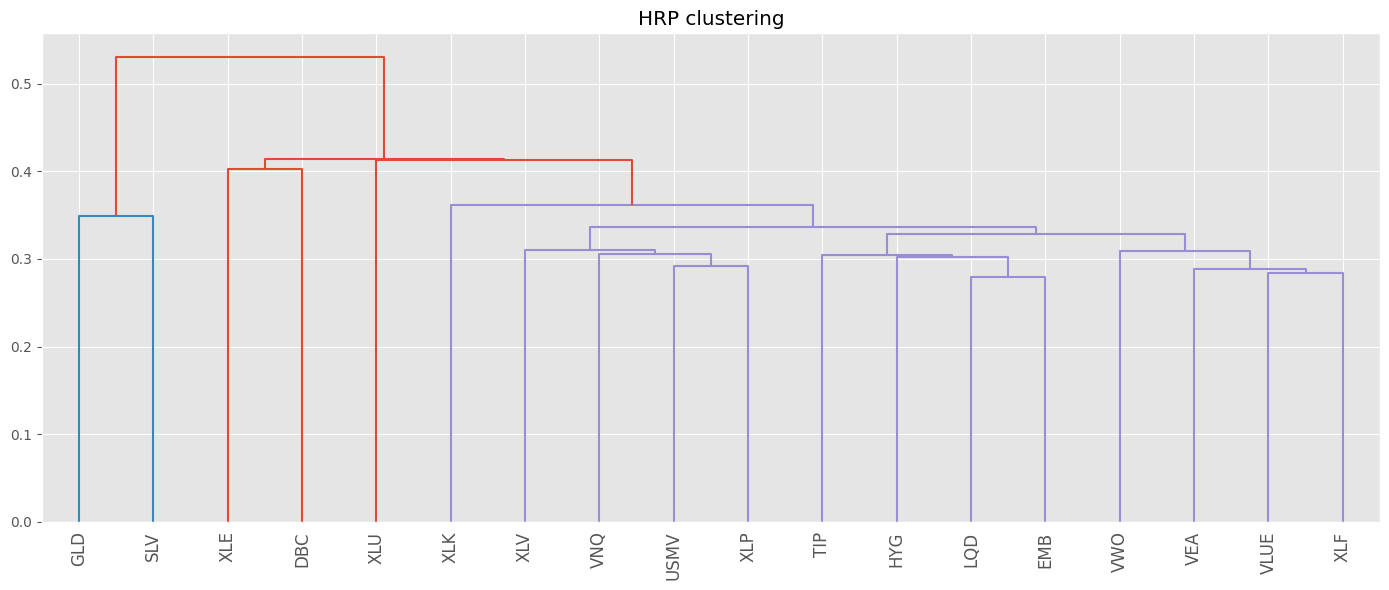

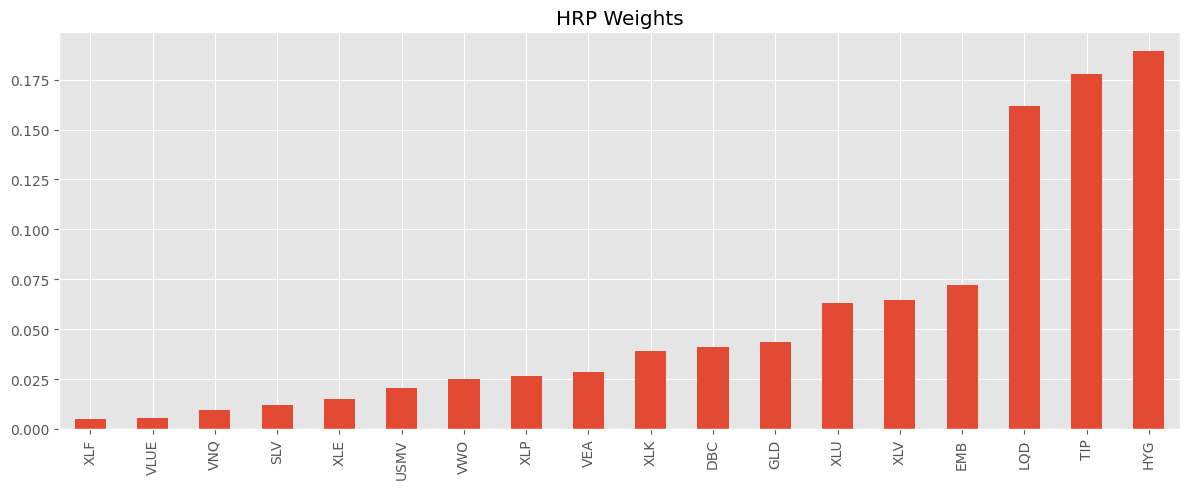

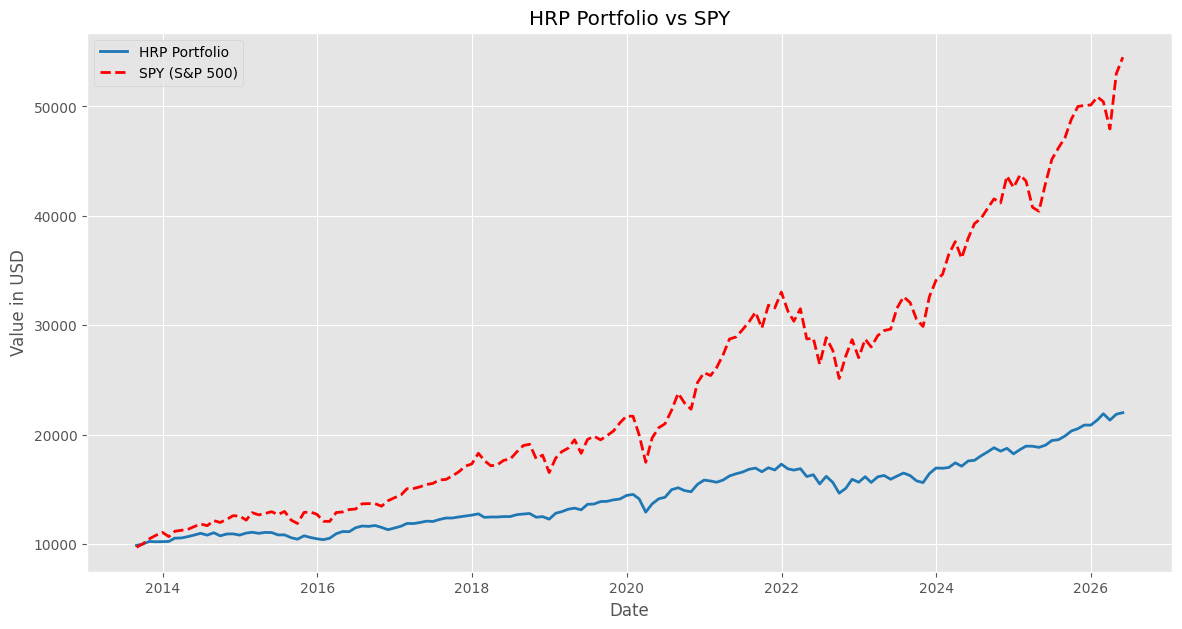

In [77]:
hrp_weights, link, ordered_assets = get_hrp_weights(
    monthly_returns_filtered
)

plt.figure(figsize=(14, 6))

plt.title("HRP clustering")

dendrogram(
    link,
    labels=monthly_returns_filtered.columns,
    leaf_rotation=90
)

plt.tight_layout()
plt.show()

hrp_weights = hrp_weights.sort_values(ascending=False)

plt.figure(figsize=(12, 5))

hrp_weights.sort_values().plot(kind="bar")

plt.title("HRP Weights")

plt.tight_layout()
plt.show()

equity_curve = initial_investment * (1 + monthly_returns_filtered.dot(hrp_weights)).cumprod()
spy = initial_investment * (1 + monthly_returns['SPY']).cumprod()
plt.figure(figsize=(14, 7))
plt.plot(equity_curve.index, equity_curve, color='#1f77b4', linewidth=2, label='HRP Portfolio')
plt.plot(spy.index, spy, color='red', linestyle='--', linewidth=2, label='SPY (S&P 500)')
plt.legend(loc='upper left')
plt.title("HRP Portfolio vs SPY")
plt.xlabel("Date")
plt.ylabel("Value in USD")
plt.grid(True)

### 4. Walk forward (out of sample) Backtest for HRP

Just like we did with the Markowitz optimization, I'm building a walk forward backtest for the HRP model. We will train the HRP weights on a rolling `lookback` window and hold them for a `step` window.

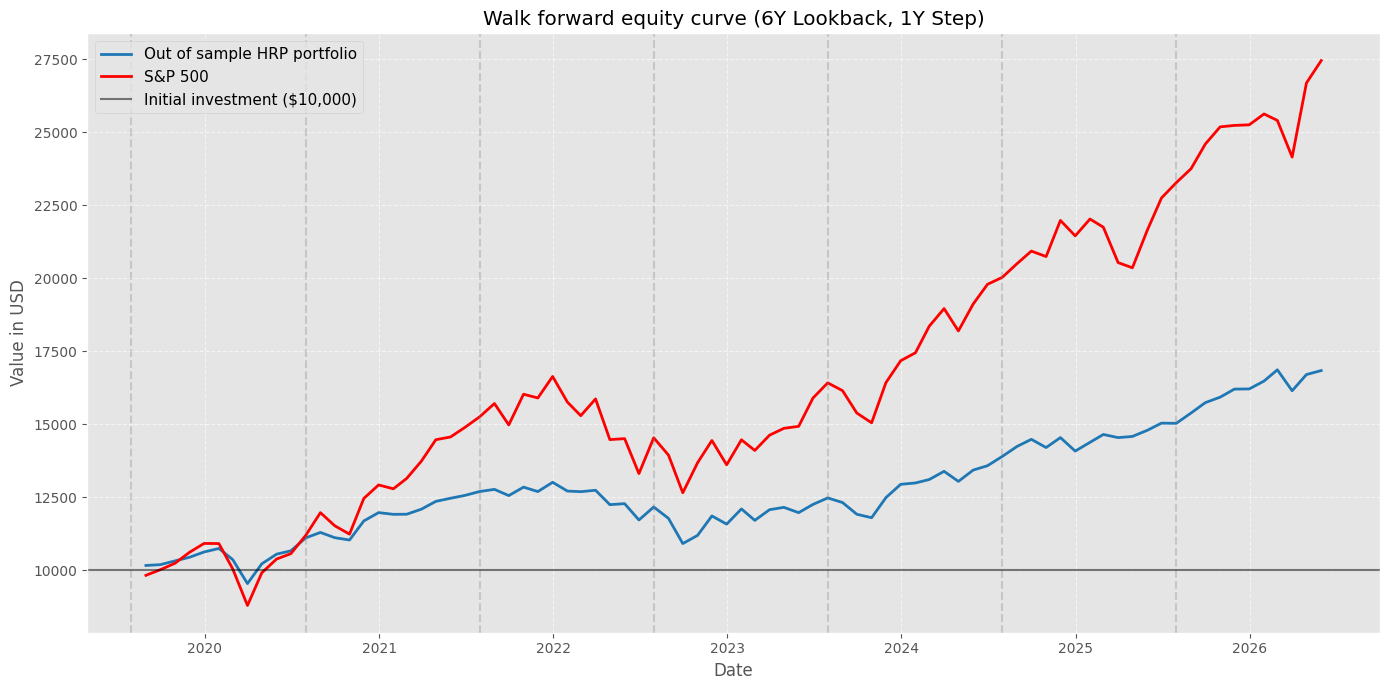

Initial value:  $10,000.00
Final value:    $16,844.52
Total return:      68.45 %
Annualized return: 7.93 % p.a.
Max drawdown:       -16.12 %
Max drawdown ($):   $-2,097.93


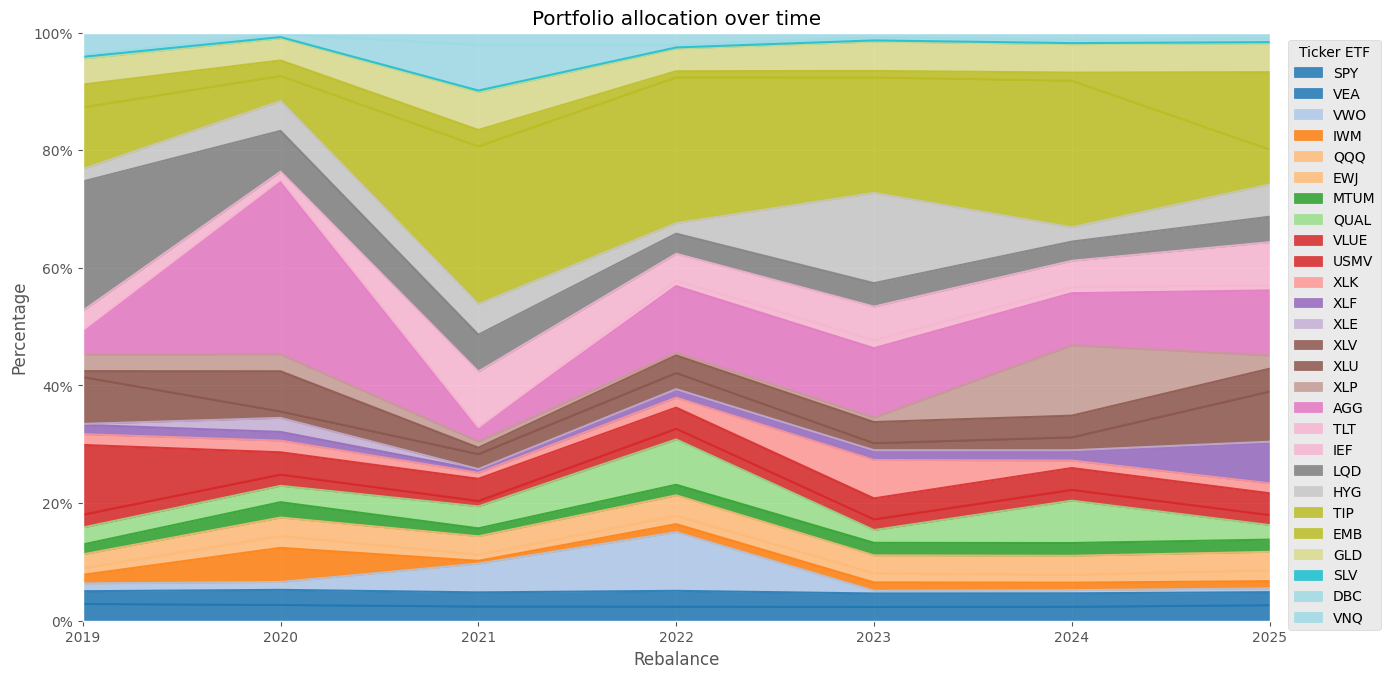

In [78]:

lookback_months = 72 
step_months = 12      
n = len(monthly_returns.columns)


oos_portfolio_returns = []
rebalance_records = [] #


total_months = len(monthly_returns)


#loop through history
for start_idx in range(0, total_months - lookback_months, step_months):
    
    # definition of train and test window
    train_end_idx = start_idx + lookback_months
    test_end_idx = min(train_end_idx + step_months, total_months)
    
    train_data = monthly_returns.iloc[start_idx:train_end_idx]
    test_data = monthly_returns.iloc[train_end_idx:test_end_idx]
    
    if test_data.empty:
        break
        
    rebalance_date = train_data.index[-1]
   
    weights,_,_ = get_hrp_weights(train_data) 
    
    #saving for later
    rebalance_records.append(pd.Series(weights, index=monthly_returns.columns, name=rebalance_date))

    # application on out of sample test data
    period_returns = test_data.dot(weights)
    oos_portfolio_returns.append(period_returns)



# get all out of sample returns in one series
oos_series = pd.concat(oos_portfolio_returns)
spy_oos_returns = monthly_returns['SPY'].loc[oos_series.index]



initial_investment = 10000
equity_curve = initial_investment * (1 + oos_series).cumprod()
spy_equity_curve = initial_investment * (1 + spy_oos_returns).cumprod()

plt.figure(figsize=(14, 7))


plt.plot(equity_curve.index, equity_curve, color='#1f77b4', linewidth=2, label='Out of sample HRP portfolio')
plt.plot(spy_equity_curve.index, spy_equity_curve, color='red', linewidth=2, label='S&P 500')

for r_date in [record.name for record in rebalance_records]:
    plt.axvline(x=r_date, color='gray', linestyle='--', alpha=0.3)

plt.axhline(y=initial_investment, color='black', linestyle='-', alpha=0.5, label='Initial investment ($10,000)')


plt.title(f'Walk forward equity curve ({lookback_months // 12}Y Lookback, 1Y Step)')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value in USD', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

plt.show()


final_value = equity_curve.iloc[-1]
total_return_pct = ((final_value / initial_investment) - 1) * 100
annualized_return = ((final_value / initial_investment) ** (1 / (len(oos_series) / 12)) - 1) * 100
peak = equity_curve.cummax()
drawdown = (equity_curve - peak) / peak

max_drawdown_pct = drawdown.min() * 100
max_drawdown_value = (equity_curve - peak).min()

print(f"Initial value:  ${initial_investment:,.2f}")
print(f"Final value:    ${final_value:,.2f}")
print(f"Total return:      {total_return_pct:.2f} %")
print(f"Annualized return: {annualized_return:.2f} % p.a.")
print(f"Max drawdown:       {max_drawdown_pct:.2f} %")
print(f"Max drawdown ($):   ${max_drawdown_value:,.2f}")


df_weights_history = pd.DataFrame(rebalance_records)


df_weights_history = df_weights_history.loc[:, (df_weights_history > 0).any(axis=0)]


plt.figure(figsize=(14, 7))


df_weights_history.plot.area(ax=plt.gca(), colormap='tab20', alpha=0.85)


plt.title('Portfolio allocation over time')
plt.xlabel('Rebalance', fontsize=12)
plt.ylabel('Percentage', fontsize=12)


plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 1) 


plt.legend(title='Ticker ETF', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()




### 5. HRP Parameter grid search

How robust is HRP to different hyperparameters compared to our mean variance setup? 

I'm running the exact same grid search across various `lookback` and `step` windows. A good, robust strategy shouldn't break just because we look back 48 months instead of 36. We are hoping to see broad, consistent colors in these heatmaps, which would indicate that the HRP algorithm is stable and less prone to overfitting.

Grid search progress: 100%|██████████| 64/64 [01:07<00:00,  1.06s/it]


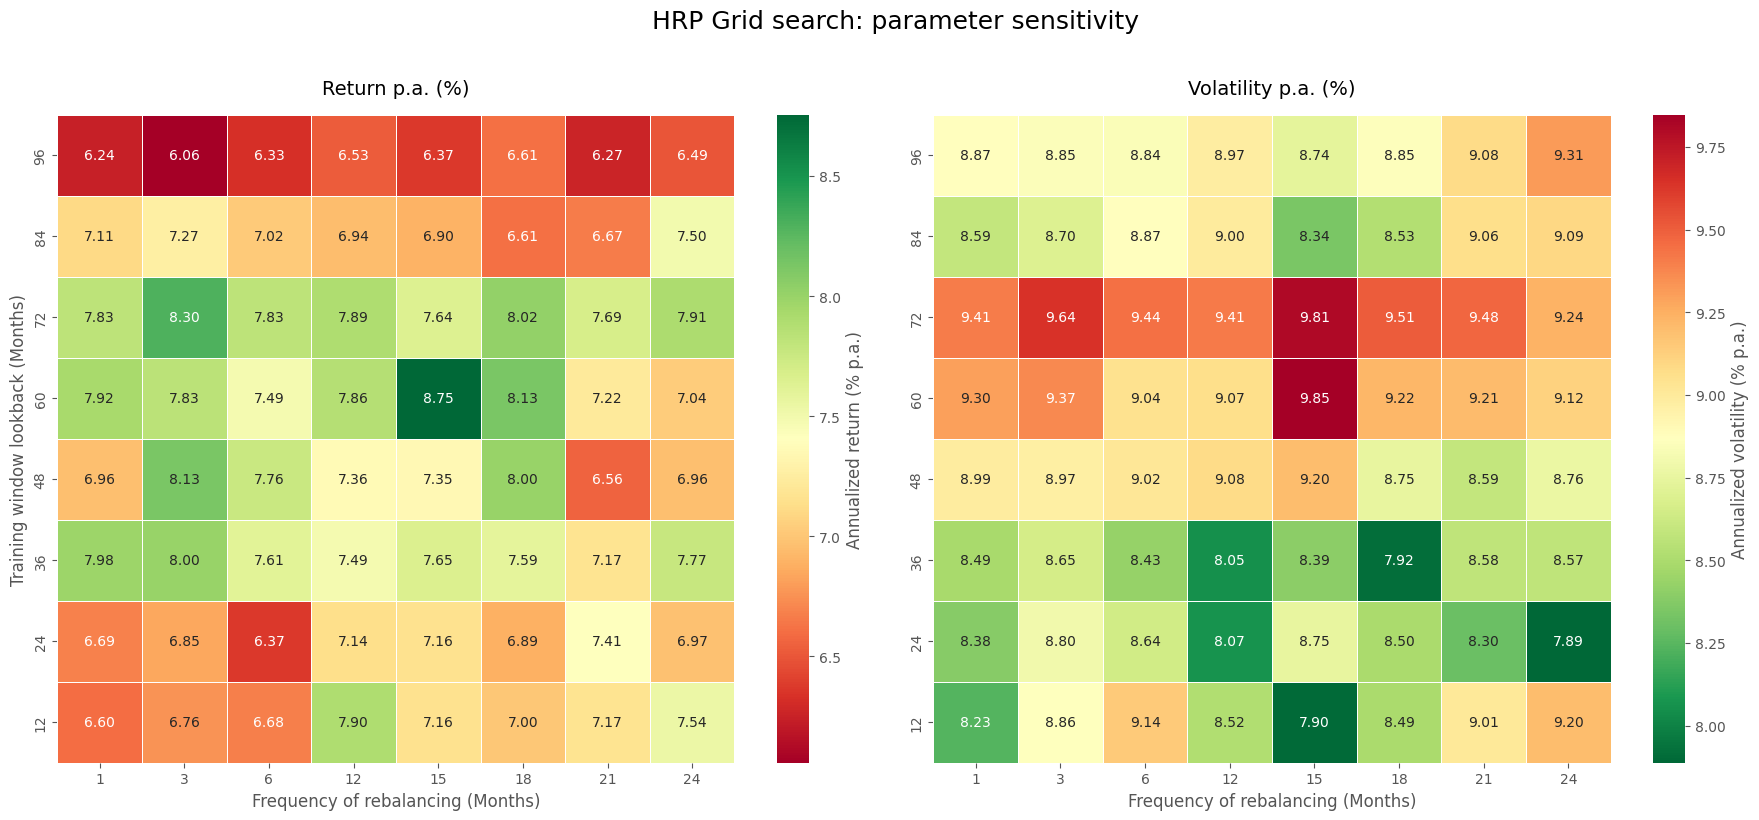

In [79]:
def run_walk_forward_backtest_hrp(lookback_months, step_months, returns_df):
   
    total_months = len(returns_df)
    oos_portfolio_returns = []
    
    for start_idx in range(0, total_months - lookback_months, step_months):
        train_end_idx = start_idx + lookback_months
        test_end_idx = min(train_end_idx + step_months, total_months)
        
        train_data = returns_df.iloc[start_idx:train_end_idx]
        test_data = returns_df.iloc[train_end_idx:test_end_idx]
        
        if test_data.empty: 
            break
            
        # get weights from HRP
        weights,_,_ = get_hrp_weights(train_data)
        
        #normalization and the tie breaker for very small weights
        weights = np.where(weights < 0.01, 0, weights)
        if np.sum(weights) > 0:
            weights = weights / np.sum(weights)
        else:
            #fallback
            weights = np.ones(len(weights)) / len(weights)
            
        period_returns = test_data.dot(weights)
        oos_portfolio_returns.append(period_returns)
        
    if not oos_portfolio_returns:
        return np.nan, np.nan
        
    oos_series = pd.concat(oos_portfolio_returns)
    cumulative_return = (1 + oos_series).prod()
    years_invested = len(oos_series) / 12
    
    if years_invested == 0: 
        return np.nan, np.nan
    

    annualized_return = ((cumulative_return ** (1 / years_invested)) - 1) * 100
    annualized_volatility = oos_series.std() * np.sqrt(12) * 100
    
    return annualized_return, annualized_volatility



lookback_grid = [12, 24, 36, 48, 60, 72, 84, 96] 
step_grid = [1, 3, 6, 12,15,18,21,24]         

results = []



total_iterations = len(lookback_grid) * len(step_grid)
with tqdm(total=total_iterations, desc="Grid search progress") as pbar:
    for lookback in lookback_grid:
        for step in step_grid:
            
            ann_ret, ann_vol = run_walk_forward_backtest_hrp(lookback, step, monthly_returns)
            
            results.append({
                'Lookback': lookback,
                'Rebalance step': step,
                'Return p.a. (%)': ann_ret,
                'Volatility p.a. (%)': ann_vol
            })
            pbar.update(1)


df_results = pd.DataFrame(results)
pivot_ret = df_results.pivot(index='Lookback', columns='Rebalance step', values='Return p.a. (%)')
pivot_vol = df_results.pivot(index='Lookback', columns='Rebalance step', values='Volatility p.a. (%)')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

#
sns.heatmap(pivot_ret, annot=True, cmap='RdYlGn', fmt=".2f", 
            linewidths=.5, cbar_kws={'label': 'Annualized return (% p.a.)'}, ax=ax1)
ax1.invert_yaxis()
ax1.set_title('Return p.a. (%)', fontsize=14, pad=15)
ax1.set_xlabel('Frequency of rebalancing (Months)', fontsize=12)
ax1.set_ylabel('Training window lookback (Months)', fontsize=12)


sns.heatmap(pivot_vol, annot=True, cmap='RdYlGn_r', fmt=".2f", 
            linewidths=.5, cbar_kws={'label': 'Annualized volatility (% p.a.)'}, ax=ax2)
ax2.invert_yaxis()
ax2.set_title('Volatility p.a. (%)', fontsize=14, pad=15)
ax2.set_xlabel('Frequency of rebalancing (Months)', fontsize=12)
ax2.set_ylabel('') 

plt.suptitle('HRP Grid search: parameter sensitivity', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 7. Conclusion


**1. The Markowitz model**
Even though it showed quite decent performance on walk forward testing, it is still subject danger to overfitting. It has the assumption that the past is the predictor of the near by future.
Could be just that the small subset of historical data we were training on is specific time window where the Markowitz model performed that well.
Also it penalizes upward deviation the same as drawdown deviation, so future work will focus on implementing the optimization to use Sortino metric as objective function.

**2. HRP model**
The absolute returns are way lower (mostly hovering between 7% and 8.5%), which makes sence since the algorithm does not use returns in any way, only the risk profile.
In result the portfolio is more stable with lower variance and is more prone to survive next regimes shifts.
